In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from config.env_config import Config
from env import UniswapV3LPGymEnv

config = Config()
env = UniswapV3LPGymEnv(config)

state, _ = env.reset()

In [2]:
cumulative_pnl_history = [env.cumulative_pnl]
time_steps = [0]
done = False
step_count = 0

for _ in range(1000):
    action = env.action_space.sample() 
    next_state, reward, done, truncated, info = env.step(action)
    step_count += 1
    cumulative_pnl_history.append(env.cumulative_pnl)
    time_steps.append(step_count)

env.close()

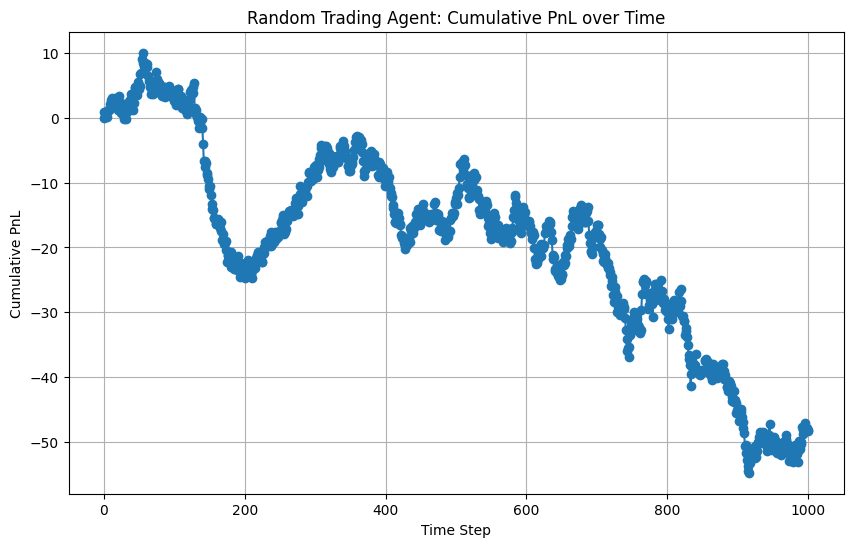

In [3]:
plt.figure(figsize=(10, 6))
plt.plot(time_steps, cumulative_pnl_history, marker="o", linestyle="-")
plt.xlabel("Time Step")
plt.ylabel("Cumulative PnL")
plt.title("Random Trading Agent: Cumulative PnL over Time")
plt.grid(True)
plt.show()